In [ ]:
# LIBRARIES

from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_community.utilities import SQLDatabase
from langchain.chains import create_sql_query_chain

from langgraph.graph import END, StateGraph

import os
import yaml
import re
from pprint import pprint
from typing import List, TypedDict

import pandas as pd
import sqlalchemy as sql

from IPython.display import Image

In [ ]:
# AI SETUP

os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

OPENAI_LLM = ChatOpenAI(
    model = "gpt-4o-mini"
)

llm = OPENAI_LLM

In [ ]:
# SQL DATABASE SETUP

PATH_DB = "sqlite:///database/leads_scored.db"

sql_engine = sql.create_engine(PATH_DB)

conn = sql_engine.connect()

In [ ]:
# HELPER FUNCTIONS

def extract_sql_code(text):
    sql_code_match = re.search(r'```sql(.*?)```', text, re.DOTALL)
    sql_code_match_2 = re.search(r"SQLQuery:\s*(.*)", text)
    if sql_code_match:
        sql_code = sql_code_match.group(1).strip()
        return sql_code
    if sql_code_match_2:
        sql_code = sql_code_match_2.group(1).strip()
        return sql_code
    else:
        sql_code_match = re.search(r"sql(.*?)'", text, re.DOTALL)
        if sql_code_match:
            sql_code = sql_code_match.group(1).strip()
            return sql_code
        else:
            return None

In [ ]:
routing_preprocessor_prompt = PromptTemplate(
    template="""
    You are an expert in routing decisions for a SQL database agent, a Charting Visualization Agent, and a Pandas Table Agent. Your job is to:
    
    1. Determine what the correct format for a Users Question should be for use with a SQL translator agent 
    2. Determine whether or not a chart should be generated or a table should be returned based on the users question.
    
    Use the following criteria on how to route the the initial user question:
    
    From the incoming user question, remove any details about the format of the final response as either a Chart or Table and return only the important part of the incoming user question that is relevant for the SQL generator agent. This will be the 'formatted_user_question_sql_only'. If 'None' is found, return the original user question.
    
    Next, determine if the user would like a data visualization ('chart') or a 'table' returned with the results of the SQL query. If unknown, not specified or 'None' is found, then select 'table'.  
    
    Return JSON with 'formatted_user_question_sql_only' and 'routing_preprocessor_decision'.
    
    INITIAL_USER_QUESTION: {initial_question}
    """,
    input_variables=["initial_question"]
)

routing_preprocessor = routing_preprocessor_prompt | llm | JsonOutputParser()

routing_preprocessor

PromptTemplate(input_variables=['initial_question'], template="\n    You are an expert in routing decisions for a SQL database agent, a Charting Visualization Agent, and a Pandas Table Agent. Your job is to:\n    \n    1. Determine what the correct format for a Users Question should be for use with a SQL translator agent \n    2. Determine whether or not a chart should be generated or a table should be returned based on the users question.\n    \n    Use the following criteria on how to route the the initial user question:\n    \n    From the incoming user question, remove any details about the format of the final response as either a Chart or Table and return only the important part of the incoming user question that is relevant for the SQL generator agent. This will be the 'formatted_user_question_sql_only'. If 'None' is found, return the original user question.\n    \n    Next, determine if the user would like a data visualization ('chart') or a 'table' returned with the results of 

In [ ]:
QUESTION = """
Which 10 customers have the highest p1 probability of purchase?
"""
response = routing_preprocessor.invoke({"initial_question": QUESTION})
response
pprint(response)

{'formatted_user_question_sql_only': 'Which 10 customers have the highest p1 '
                                     'probability of purchase?',
 'routing_preprocessor_decision': 'table'}


In [ ]:
QUESTION = """
What are the total sales by month-year? Return a chart of sales by month-year. 
"""
response = routing_preprocessor.invoke({"initial_question": QUESTION})
response

{'formatted_user_question_sql_only': 'What are the total sales by month-year?',
 'routing_preprocessor_decision': 'chart'}

In [ ]:
QUESTION = """
What are the total sales by month-year? Please return a table. 
"""
response = routing_preprocessor.invoke({"initial_question": QUESTION})
response

{'formatted_user_question_sql_only': 'What are the total sales by month-year?',
 'routing_preprocessor_decision': 'table'}

In [ ]:
response['formatted_user_question_sql_only']

'What are the total sales by month-year?'

In [ ]:
response['routing_preprocessor_decision']

'table'

In [ ]:
db = SQLDatabase.from_uri(PATH_DB)

sql_generator = create_sql_query_chain(
    llm = llm,
    db = db,
    k = int(1e7)
)

sql_generator

RunnableAssign(mapper={
  input: RunnableLambda(...),
  table_info: RunnableLambda(...)
})
| RunnableLambda(lambda x: {k: v for (k, v) in x.items() if k not in ('question', 'table_names_to_use')})
| PromptTemplate(input_variables=['input', 'table_info'], partial_variables={'top_k': '10000000'}, template='You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.\nUnless the user specifies in the question a specific number of examples to obtain, query for at most {top_k} results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.\nNever query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.\nPay attention to use only the column names you can see in the tables

In [ ]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.
    """
    user_question: str
    formatted_user_question_sql_only: str
    sql_query : str
    data: dict
    routing_preprocessor_decision: str

In [ ]:
def preprocess_routing(state):
    print("---ROUTER---")
    question = state.get("user_question")
    
    # Chart Routing and SQL Prep
    response = routing_preprocessor.invoke({"initial_question": question})
    
    formatted_user_question_sql_only = response['formatted_user_question_sql_only']
    
    routing_preprocessor_decision = response['routing_preprocessor_decision']
    
    return {
        "formatted_user_question_sql_only": formatted_user_question_sql_only,
        "routing_preprocessor_decision": routing_preprocessor_decision,
    }

In [ ]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("formatted_user_question_sql_only")
    
    # Handle case when formatted_user_question_sql_only is None:
    if question is None:
        question = state.get("user_question")
        
    # Generate SQL
    sql_query = sql_generator.invoke({"question": question})
    
    # Extract SQL code
    sql_query = extract_sql_code(sql_query)
    
    return {"sql_query": sql_query}

In [ ]:
def convert_dataframe(state):
    print("---CONVERT DATA FRAME---")

    sql_query = state.get("sql_query")
    
    df = pd.read_sql(sql_query, conn)
    
    return {"data": dict(df)}

In [ ]:
def decide_chart_or_table(state):
    print("---DECIDE CHART OR TABLE---")
    return "chart" if state.get('routing_preprocessor_decision') == "chart" else "table"

In [ ]:
def generate_chart(state):
    print("---GENERATE CHART---")
    
    # TODO: Add Charting Logic
    
    return {}

In [ ]:
def state_printer(state):
    """print the state"""
    print("---STATE PRINTER---")
    print(f"User Question: {state['user_question']}")
    print(f"Formatted Question (SQL): {state['formatted_user_question_sql_only']}")
    pprint(f"SQL Query: \n{state['sql_query']}\n")
    print(f"Chart or Table: {state['routing_preprocessor_decision']}")
    print(f"Data: \n{pd.DataFrame(state['data'])}\n")

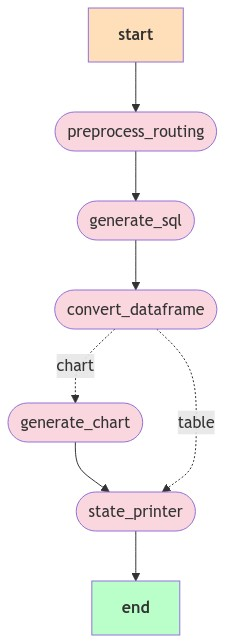

In [ ]:
workflow = StateGraph(GraphState)

workflow.add_node("preprocess_routing", preprocess_routing)
workflow.add_node("generate_sql", generate_sql)
workflow.add_node("convert_dataframe", convert_dataframe)
workflow.add_node("generate_chart", generate_chart)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("preprocess_routing")
workflow.add_edge("preprocess_routing", "generate_sql")
workflow.add_edge("generate_sql", "convert_dataframe")

# NEW: Conditional Edges

workflow.add_conditional_edges(
    "convert_dataframe", 
    decide_chart_or_table,
    {
        # Result : Step Name To Go To
        "chart":"generate_chart", # Path Chart
        "table":"state_printer" # Path State Printer
    }
)

workflow.add_edge("generate_chart", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()

Image(app.get_graph().draw_mermaid_png())

In [ ]:
QUESTION = """
Which 10 customers have the highest p1 probability of purchase?
"""
inputs = {"user_question": QUESTION, "num_steps": 0}
for s in app.stream(inputs):
    print(s)

---ROUTER---
{'preprocess_routing': {'formatted_user_question_sql_only': 'Which 10 customers have the highest p1 probability of purchase?', 'routing_preprocessor_decision': 'table'}}
---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "user_full_name", "user_email", "p1" \nFROM "leads_scored" \nORDER BY "p1" DESC \nLIMIT 10;'}}
---CONVERT DATA FRAME---
---DECIDE CHART OR TABLE---
{'convert_dataframe': {'data': {'user_full_name': 0            Kecia Johnson
1          Estel Abernathy
2      Peter Morar-Lebsack
3    Dr. Alana Hermann DDS
4          Bedford Farrell
5    Mr. Ephraim Ankunding
6           Doloris Larkin
7            Chase Pfeffer
8      Mr. Volney White Sr
9            Dr. Savon Von
Name: user_full_name, dtype: object, 'user_email': 0           kecia.johnson@gmail.com
1         estel.abernathy@gmail.com
2      peter.morarlebsack@gmail.com
3    dr.alana.hermann.dds@gmail.com
4         bedford.farrell@yahoo.com
5    mr.ephraim.ankunding@gmail.com
6          doloris.larki

In [ ]:
QUESTION = """
What are the first five rows of each table?
"""
inputs = {"user_question": QUESTION, "num_steps": 0}
for s in app.stream(inputs):
    print(s)

---ROUTER---
{'preprocess_routing': {'formatted_user_question_sql_only': 'What are the first five rows of each table?', 'routing_preprocessor_decision': 'table'}}
---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "mailchimp_id", "user_full_name", "user_email", "member_rating", "optin_time", "country_code", "made_purchase", "optin_days", "email_provider" FROM leads LIMIT 5;'}}
---CONVERT DATA FRAME---
---DECIDE CHART OR TABLE---
{'convert_dataframe': {'data': {'mailchimp_id': 0     3
1     4
2     8
3    10
4    11
Name: mailchimp_id, dtype: int64, 'user_full_name': 0      Garrick Langworth
1        Cordell Dickens
2              Inga Dach
3    Ferdinand Bergstrom
4         Justen Simonis
Name: user_full_name, dtype: object, 'user_email': 0      garrick.langworth@gmail.com
1        cordell.dickens@gmail.com
2              inga.dach@gmail.com
3    ferdinand.bergstrom@gmail.com
4         justen.simonis@gmail.com
Name: user_email, dtype: object, 'member_rating': 0    2
1    4
2    

In [ ]:
QUESTION = """
What are the names of each table?
"""
inputs = {"user_question": QUESTION, "num_steps": 0}
for s in app.stream(inputs):
    print(s)

---ROUTER---
{'preprocess_routing': {'formatted_user_question_sql_only': 'What are the names of each table?', 'routing_preprocessor_decision': 'table'}}
---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "name" FROM sqlite_master WHERE "type"=\'table\';'}}
---CONVERT DATA FRAME---
---DECIDE CHART OR TABLE---
{'convert_dataframe': {'data': {'name': 0     transactions
1         products
2            leads
3     leads_scored
4    message_store
Name: name, dtype: object}}}
---STATE PRINTER---
User Question: 
What are the names of each table?

Formatted Question (SQL): What are the names of each table?
'SQL Query: \nSELECT "name" FROM sqlite_master WHERE "type"=\'table\';\n'
Chart or Table: table
Data: 
            name
0   transactions
1       products
2          leads
3   leads_scored
4  message_store



In [ ]:
QUESTION = """
Extract the transactions table. Return all rows.
"""
inputs = {"user_question": QUESTION, "num_steps": 0}
for s in app.stream(inputs):
    print(s)

---ROUTER---
{'preprocess_routing': {'formatted_user_question_sql_only': 'Extract the transactions table.', 'routing_preprocessor_decision': 'table'}}
---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "transaction_id", "purchased_at", "user_full_name", "user_email", "charge_country", "product_id" FROM transactions LIMIT 10000000;'}}
---CONVERT DATA FRAME---
---DECIDE CHART OR TABLE---
{'convert_dataframe': {'data': {'transaction_id': 0          1
1          2
2          3
3          4
4          5
        ... 
4657    4658
4658    4659
4659    4660
4660    4661
4661    4662
Name: transaction_id, Length: 4662, dtype: int64, 'purchased_at': 0       2018-04-29
1       2018-04-29
2       2018-04-29
3       2018-04-29
4       2018-04-29
           ...    
4657    2020-12-31
4658    2020-12-31
4659    2020-12-31
4660    2020-12-31
4661    2020-12-31
Name: purchased_at, Length: 4662, dtype: object, 'user_full_name': 0                Deliah Kemmer
1        Dr. Ronal Keeling DVM
2      

In [ ]:
QUESTION = """
What are the total sales by month-year? Make a chart of sales over time.
"""
inputs = {"user_question": QUESTION, "num_steps": 0}
for s in app.stream(inputs):
    print(s)

---ROUTER---
{'preprocess_routing': {'formatted_user_question_sql_only': 'What are the total sales by month-year?', 'routing_preprocessor_decision': 'chart'}}
---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT strftime(\'%Y-%m\', "purchased_at") AS "month_year", COUNT("transaction_id") AS "total_sales"\nFROM "transactions"\nGROUP BY "month_year"\nORDER BY "month_year";'}}
---CONVERT DATA FRAME---
---DECIDE CHART OR TABLE---
{'convert_dataframe': {'data': {'month_year': 0     2018-04
1     2018-05
2     2018-06
3     2018-07
4     2018-08
5     2018-09
6     2018-10
7     2018-11
8     2018-12
9     2019-01
10    2019-02
11    2019-03
12    2019-04
13    2019-05
14    2019-06
15    2019-07
16    2019-08
17    2019-09
18    2019-10
19    2019-11
20    2019-12
21    2020-01
22    2020-02
23    2020-03
24    2020-04
25    2020-05
26    2020-06
27    2020-07
28    2020-08
29    2020-09
30    2020-10
31    2020-11
32    2020-12
Name: month_year, dtype: object, 'total_sales': 0      14